In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

import numpy as np
import sys, pickle, os, torch, cv2
# replace this path with path to GMIC
#sys.path.append("/path/to/GMIC")

from src.data_loading import loading
from src.modeling import gmic as gmic

from PIL import Image

### You need to obtain the cropped images (bash run.sh) before using this demo.

Step 1: prepare the input data

In [2]:
with open("sample_output/data.pkl", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list[1])
print(exam_list[1]["horizontal_flip"])
datum = exam_list[1]
view = "R-MLO"
short_file_path = datum[view][0]
print(short_file_path)

{'examID': 'DBT-P02919', 'horizontal_flip': 'YES', 'L-MLO': ['1_L-MLO'], 'L-MLO_path': 'sample_data/dicom_exams/DBT-P02919/01-01-2000-DBT-S01259-MAMMO screening digital bilateral-68030/12893.000000-24570', 'L-CC': ['1_L-CC'], 'L-CC_path': 'sample_data/dicom_exams/DBT-P02919/01-01-2000-DBT-S01259-MAMMO screening digital bilateral-68030/12892.000000-81829', 'R-MLO': ['1_R-MLO'], 'R-MLO_path': 'sample_data/dicom_exams/DBT-P02919/01-01-2000-DBT-S01259-MAMMO screening digital bilateral-68030/12895.000000-12883', 'R-CC': ['1_R-CC'], 'R-CC_path': 'sample_data/dicom_exams/DBT-P02919/01-01-2000-DBT-S01259-MAMMO screening digital bilateral-68030/12894.000000-34445', 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}, 'window_location': {'L-CC': [(0, 2321, 493, 1996)], 'R-CC': [(28, 2302, 0, 1428)], 'L-MLO': [(0, 2355, 341, 1996)], 'R-MLO': [(0, 2385, 0, 1519)]}, 'rightmost_points': {'L-CC': [((1120, 1213), 1

Step 2: load the image

<class 'numpy.ndarray'>
0.0
1001.0
(2385, 1519)


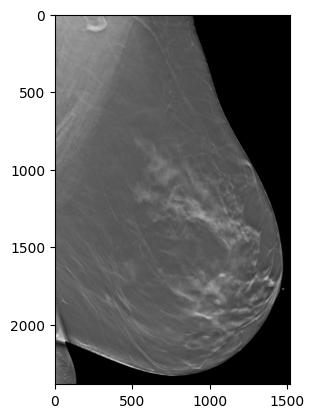

In [3]:
loaded_image = loading.read_image(os.path.join("sample_output/cropped_images/", short_file_path + ".png"))

print(type(loaded_image))
print(np.min(loaded_image))
print(np.max(loaded_image))
print(loaded_image.shape)

plt.imshow(loaded_image, cmap="gray")

Step 3: preprocess the image

In [4]:
loaded_image = loading.process_image(loaded_image, view, datum["horizontal_flip"], datum["best_center"][view][0])

Let's visualize a sample image

(2944, 1920)
4.0585184


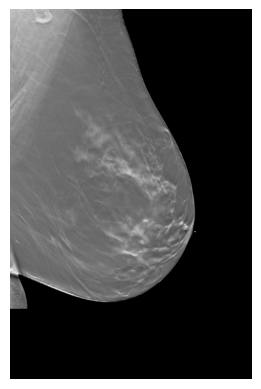

In [5]:
print(loaded_image.shape)
print(np.max(loaded_image))
plt.imshow(loaded_image, cmap="Greys_r")
plt.axis("off")
plt.savefig("mammoOriginal.png")
plt.show()

Step 4: load the model

In [6]:
parameters = {
        "device_type":"cpu",
        "cam_size": (46, 30),
        "K": 6,
        "crop_shape": (256, 256),
        "percent_t": 0.02, 
        "post_processing_dim": 256,
        "num_classes": 2
    }

In [7]:
model = gmic.GMIC(parameters)

In [8]:
model.load_state_dict(torch.load("models/sample_model_2.p", map_location="cpu"), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['shared_rep_filter.weight'])

Step 5: inference

In [12]:
tensor_batch = torch.Tensor(np.expand_dims(np.expand_dims(loaded_image, 0), 0).copy())
output = model(tensor_batch)
pred_numpy = output.data.cpu().numpy()
benign_pred = pred_numpy[0,0]
malignant_pred = pred_numpy[0, 1]

In [10]:
print("benign prediction = {}".format(benign_pred))
print("malignant prediction = {}".format(malignant_pred))

benign prediction = 0.3139348328113556
malignant prediction = 0.06017734482884407


Step 6: visualize the saliency map

(1, 2, 46, 30)


/var/folders/d7/q72cpd5d6bv6knpx85s28lq80000gn/T/ipykernel_77220/728397749.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  alpha_red = plt.cm.get_cmap('Reds')


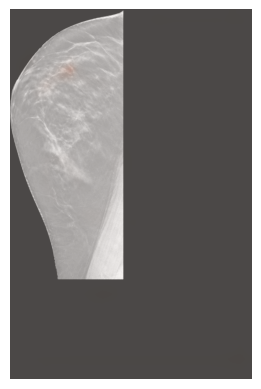

In [34]:
saliency_maps = model.saliency_map.data.cpu().numpy()
print(saliency_maps.shape)
malignant_saliency_map = saliency_maps[0,1,:,:]
alphas = np.abs(np.linspace(0, 0.95, 259))
alpha_red = plt.cm.get_cmap('Reds')
plt.figure()
plt.imshow(loaded_image, cmap="Greys_r")
plt.imshow(cv2.resize(malignant_saliency_map, (1920, 2944)), alpha=0.3, cmap=alpha_red, clim=[0.0, 1.0])
plt.axis("off")
plt.savefig("mammoResult.png")
plt.show()